In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
sys.path.append('../')
from CEmulator.Emulator import CBaseEmulator

Omegab = 0.055
Omegam = 0.353
H0     = 63.6
ns     = 0.964
sigma8 = 0.781
mnu    = 0.06  # One single massive neutrino with two massless neutrinos
w      = -0.42
wa     = -1.75
Omegan = mnu/93.14/H0**2 * 1e4
Omegacb  = round(Omegam-Omegan, 8)
Omegac   = Omegacb - Omegab
print(Omegacb, Omegac)

csstemu = CBaseEmulator(verbose=True)
zlists  = np.array([0.0, 1.0, 2.0, 3.0])
##### need extra package [CLASS/CAMB] to transform sigma8 to As
csstemu.set_cosmos(Omegab=Omegab, Omegac=Omegac, H0=H0, sigma8=sigma8, ns=ns, 
                   w=w, wa=wa, mnu=mnu, checkbound=False, sigma8type='CLASS')
As = csstemu.Cosmo.As
print(As)

0.35140742 0.29640742000000003
Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
The As is set to 2.082799e-09 (sigma8=0.781000) to match the input sigma8=0.781000.
2.0827988478868847e-09


In [3]:
#First, obtain the equivalent w0, wa for the original cosmology
from CEmulator.SpectralEquivalence import SpectralEquivalence_DE

w0_arr, wa_arr = SpectralEquivalence_DE(csstemu, zlists, wCDM=False)
print(w0_arr)
print(wa_arr)

[-0.73511118 -0.86680234 -0.97378501 -1.04211963]
[-0.5 -0.5 -0.5 -0.5]


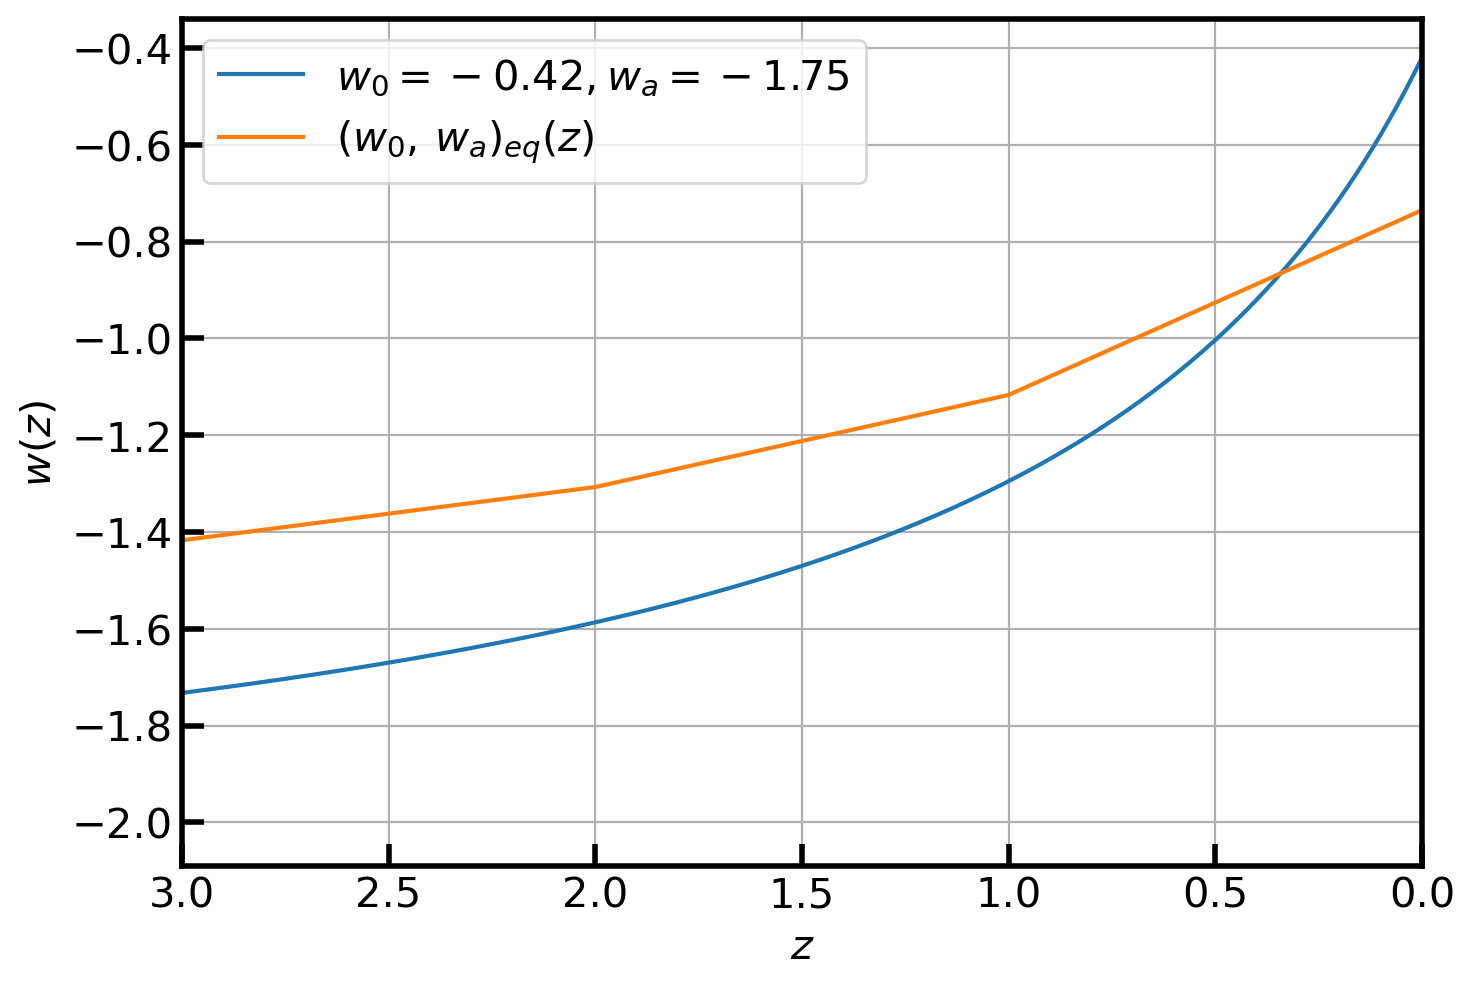

In [4]:
ztt = np.linspace(0, 10, 1000)
with plt.style.context('article'):
    plt.plot(ztt, (w+wa*ztt/(1+ztt)), label=r"$w_0=%.2f, w_a=%.2f$"%(w, wa))
    plt.plot(zlists, (w0_arr + wa_arr*zlists/(1+zlists)), label=r"$(w_0,\, w_a)_{eq}(z)$")
    plt.xlim(3, 0)
    plt.grid(True)
    plt.legend()
    plt.xlabel(r'$z$')
    plt.ylabel(r"$w(z)$")

In [5]:
# Then, obtain the equivalent As for the original cosmology
from CEmulator.SpectralEquivalence import SpectralEquivalence_As

Aseq_arr = SpectralEquivalence_As(csstemu, zlists, w0_arr, wa_arr, sigma8_type='CLASS')
print(As * 1e9)
print(Aseq_arr * 1e9)

2.0827988478868846
[2.10751766 2.0857566  2.08094917 2.08046926]


In [6]:
# Then, obtain the equivalent As for the original cosmology
from CEmulator.SpectralEquivalence import SpectralEquivalence_As

Aseq_arr = SpectralEquivalence_As(csstemu, zlists, w0_arr, wa_arr, sigma8_type='CAMB')
print(As * 1e9)
print(Aseq_arr * 1e9)

2.0827988478868846
[2.1093485  2.08752051 2.08267343 2.08216965]
